# Stress Testing and Scenario Analysis
**Docker image**: `ml4t`

**Purpose**: Replay historical crises, apply user-defined scenario shocks, and
run Monte Carlo simulations on a panel of canonical ETF allocations to quantify
tail behaviour and contrast portfolio robustness.

**Learning objectives**:
1. Reproduce portfolio losses during the 2008 GFC, 2020 COVID, and 2022 Fed
   tightening windows for four reference allocations (60/40, All Weather,
   Aggressive Equity, Defensive).
2. Define hand-authored simultaneous-shock scenarios and apply them via a weighted sum.
3. Run a symmetric Student-t Monte Carlo with kurtosis-matched degrees of freedom and read the
   resulting loss quantiles and expected shortfall over a multi-week horizon.
4. Compare regime-conditional return statistics (Bull / Calm / High Vol / Bear).

**Book reference**: §19.6 (Stress Testing and Scenario Analysis); also cited
from §19.1 and §19.2.

**Prerequisites**: `01_var_cvar` for what VaR and CVaR measure and how a drawdown is defined,
Chapter 17 for portfolio construction, and comfort treating stress tables as decision support
rather than point forecasts. This notebook loads its own price panel and reads no artifact from
any other.

**Data**: Canonical ETF panel via `data.load_etfs()` for SPY, EFA, EEM, AGG,
TLT, GLD, VNQ; window 2007-01-01 to 2024-01-01.

## Setup

In [1]:
"""Replay historical crises, design scenarios, and simulate portfolio tails."""

from dataclasses import dataclass
from datetime import date

import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import polars as pl
from IPython.display import Markdown, display
from plotly.subplots import make_subplots
from scipy import stats

from data import load_etfs
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, ml4t_diverging, ml4t_palette, show_plotly_with_alt

In [2]:
SEED = 42
N_SIMULATIONS = 10_000
HORIZON_DAYS = 20
CONFIDENCE_LEVELS = (0.95, 0.99, 0.999)
REGIME_LOOKBACK = 60
BEAR_TREND_THRESHOLD = -0.05
BULL_TREND_THRESHOLD = 0.10
HIGH_VOL_MULTIPLE = 1.3

In [3]:
set_global_seeds(SEED)

What each setting decides:

- `N_SIMULATIONS` and `HORIZON_DAYS` size the Monte Carlo: how many paths are drawn and how far
  ahead each runs. The horizon is a few trading weeks, which is the span over which a risk
  committee would ask what a bad outcome looks like.
- `CONFIDENCE_LEVELS` are the loss quantiles reported. The deepest of them is estimated from a
  handful of the drawn paths, so it moves noticeably between seeds and should be read as an
  order of magnitude.
- `REGIME_LOOKBACK` is the window the market state is read from - both the trailing volatility
  and the trend. It also sets how long the classifier waits before labelling anything.
- `BEAR_TREND_THRESHOLD` and `BULL_TREND_THRESHOLD` are the annualized trailing returns that
  separate a falling market from a rising one, and `HIGH_VOL_MULTIPLE` is how far above its own
  historical median trailing volatility has to sit before a day counts as stressed. All three are
  round numbers chosen to split this sample into usable groups, not estimated boundaries.

`max_drawdown` returns the most negative point of the equity curve
relative to its running peak (a percentage, not an absolute wealth
difference). It is the single drawdown definition used throughout the
stress-period replay, sensitivity analysis, and regime tables below.

In [4]:
def max_drawdown(returns_array: np.ndarray) -> float:
    """Compute percentage maximum drawdown from a 1D returns series."""

    values = np.asarray(returns_array, dtype=float)
    if values.ndim != 1 or not np.isfinite(values).all():
        raise ValueError("returns_array must be one-dimensional and finite")
    if values.size == 0:
        return 0.0
    if np.any(values <= -1):
        raise ValueError("simple returns must be greater than -100%")

    equity_curve = np.concatenate(([1.0], np.cumprod(1 + values)))
    running_peak = np.maximum.accumulate(equity_curve)
    drawdown = equity_curve / running_peak - 1
    return float(drawdown.min())

## 1. Historical Data

In [5]:
# Load diversified portfolio from canonical ETF universe
SYMBOLS = {
    "SPY": "US Equity",
    "EFA": "Int'l Equity",
    "EEM": "EM Equity",
    "AGG": "US Bonds",
    "TLT": "Long Treasury",
    "GLD": "Gold",
    "VNQ": "Real Estate",
}

START_DATE = "2007-01-01"  # Include 2008 crisis
END_DATE = "2024-01-01"

etf_filtered = load_etfs(
    symbols=list(SYMBOLS),
    start_date=START_DATE,
    end_date=END_DATE,
).sort(["symbol", "timestamp"])

# Pivot to wide format
close_prices = (
    etf_filtered.select(["timestamp", "symbol", "close"])
    .pivot(on="symbol", index="timestamp", values="close")
    .sort("timestamp")
    .select("timestamp", *SYMBOLS)
    .with_columns(pl.col(list(SYMBOLS)).forward_fill())
    .drop_nulls()
)
returns = (
    close_prices.with_columns(
        (pl.col(symbol) / pl.col(symbol).shift(1) - 1).alias(symbol) for symbol in SYMBOLS
    )
    .drop_nulls()
    .sort("timestamp")
)

print(f"Loaded {returns.height:,} daily returns from canonical data")

Loaded 4,277 daily returns from canonical data


The return panel spans the crises we want to replay, so it gives the notebook one consistent
base dataset for historical stress, hypothetical shocks, and simulated tail scenarios.

## 2. Historical Crisis Periods

Define major market stress events for analysis. Each tuple contains two
observed closing-session endpoints. Portfolio returns are compounded over
`(start close, end close]`, so the starting capital is explicit and the first
included return is the session after `start`.

In [6]:
# Major historical stress periods
STRESS_PERIODS = {
    "2008 GFC Selloff": ("2008-09-02", "2009-03-09"),
    "2010 Flash Crash and Next Session": ("2010-05-05", "2010-05-07"),
    "2011 US Debt Downgrade Selloff": ("2011-08-03", "2011-08-08"),
    "2015 China Devaluation Selloff": ("2015-08-17", "2015-08-25"),
    "2018 Q4 Selloff": ("2018-10-01", "2018-12-24"),
    "2020 COVID Peak-to-Trough": ("2020-02-19", "2020-03-23"),
    "2022 Tightening Jan-to-Oct Selloff": ("2022-01-03", "2022-10-12"),
}
STRESS_PLOT_LABELS = {
    "2008 GFC Selloff": "2008 GFC",
    "2010 Flash Crash and Next Session": "2010 Flash Crash",
    "2011 US Debt Downgrade Selloff": "2011 Debt Downgrade",
    "2015 China Devaluation Selloff": "2015 China Devaluation",
    "2018 Q4 Selloff": "2018 Q4 Selloff",
    "2020 COVID Peak-to-Trough": "2020 COVID",
    "2022 Tightening Jan-to-Oct Selloff": "2022 Tightening",
}

Portfolio aggregation below requires complete asset returns and weights that sum to one. It
implements a constant-weight portfolio rebalanced at each daily close, before costs. That
assumption makes crisis comparisons consistent but can overstate implementability during stress.

In [7]:
def aggregate_portfolio_returns(
    asset_returns: pl.DataFrame,
    portfolio_weights: dict[str, float],
) -> pl.DataFrame:
    """Aggregate complete asset returns with validated constant daily weights."""

    if not np.isclose(sum(portfolio_weights.values()), 1.0, rtol=0, atol=1e-12):
        raise ValueError("portfolio weights must sum to one")
    missing_assets = sorted(set(portfolio_weights) - set(asset_returns.columns))
    if missing_assets:
        raise KeyError(f"missing return columns: {missing_assets}")

    selected = asset_returns.select("timestamp", *portfolio_weights)
    invalid = selected.select(
        pl.any_horizontal(
            [pl.col(asset).is_null() | pl.col(asset).is_nan() for asset in portfolio_weights]
        ).any()
    ).item()
    if invalid:
        raise ValueError("portfolio aggregation does not permit missing returns")
    return selected.select(
        "timestamp",
        pl.sum_horizontal(
            [pl.col(asset) * weight for asset, weight in portfolio_weights.items()]
        ).alias("portfolio_return"),
    )

The stress helper treats each boundary as a close endpoint, validates that both are observed
sessions, and reports the actual included return labels. This avoids silently snapping a holiday
or weekend boundary to a different economic window.

In [8]:
def slice_stress_window(
    returns: pl.DataFrame,
    start_date: str,
    end_date: str,
) -> tuple[pl.DataFrame, date, date]:
    """Select return labels in an explicit `(start close, end close]` interval."""

    if returns.schema.get("timestamp") != pl.Date:
        raise TypeError("stress replay requires canonical daily timestamps with Polars Date dtype")
    start = date.fromisoformat(start_date)
    end = date.fromisoformat(end_date)
    endpoints = returns.filter(pl.col("timestamp").is_in([start, end]))["timestamp"].n_unique()
    if endpoints != 2:
        raise ValueError(f"stress endpoints must be observed sessions: {start} to {end}")
    if start >= end:
        raise ValueError("stress start endpoint must precede the end endpoint")
    period_returns = returns.filter(pl.col("timestamp") > start, pl.col("timestamp") <= end)
    if period_returns.is_empty():
        raise ValueError("stress window contains no return observations")
    return period_returns, start, end

With the interval fixed, the analysis helper applies the validated portfolio aggregation and
computes contiguous close-to-close stress statistics.

In [9]:
def analyze_stress_period(
    returns: pl.DataFrame,
    start_date: str,
    end_date: str,
    portfolio_weights: dict[str, float] | None = None,
) -> dict:
    """Analyze portfolio performance during a stress period."""

    period_returns, start, end = slice_stress_window(returns, start_date, end_date)
    if portfolio_weights is None:
        assets = [column for column in returns.columns if column != "timestamp"]
        portfolio_weights = {symbol: 1 / len(assets) for symbol in assets}
    portfolio_ret = aggregate_portfolio_returns(period_returns, portfolio_weights)
    portfolio_values = portfolio_ret["portfolio_return"].to_numpy()
    cum_return = np.prod(1 + portfolio_values) - 1
    max_dd = max_drawdown(portfolio_values)
    asset_cumulative = {
        asset: np.prod(1 + period_returns[asset].to_numpy()) - 1
        for asset in returns.columns
        if asset != "timestamp"
    }
    return {
        "first_return_label": period_returns["timestamp"].min(),
        "end_close": end,
        "cum_return": cum_return,
        "max_drawdown": max_dd,
        "days": period_returns.height,
        "worst_day": portfolio_values.min(),
        "best_day": portfolio_values.max(),
        "volatility": portfolio_values.std(ddof=1) * np.sqrt(252),
        "asset_returns": asset_cumulative,
    }

In [10]:
# Analyze all stress periods with equal-weight portfolio
print("Historical Stress Period Analysis")
print("=" * 70)

stress_results = {}
for name, (start, end) in STRESS_PERIODS.items():
    result = analyze_stress_period(returns, start, end)
    stress_results[name] = result
    print(f"\n{name}: close {start} to close {end}")
    print(
        f"  Return labels: {result['first_return_label']:%Y-%m-%d} to "
        f"{result['end_close']:%Y-%m-%d} ({result['days']} sessions)"
    )
    print(f"  Portfolio:    {result['cum_return'] * 100:+.2f}%")
    print(f"  Max Drawdown: {result['max_drawdown'] * 100:.2f}%")
    print(f"  Worst Day:    {result['worst_day'] * 100:.2f}%")
    print(f"  Volatility:   {result['volatility'] * 100:.1f}% (ann.)")

Historical Stress Period Analysis

2008 GFC Selloff: close 2008-09-02 to close 2009-03-09
  Return labels: 2008-09-03 to 2009-03-09 (129 sessions)
  Portfolio:    -27.03%
  Max Drawdown: -31.14%
  Worst Day:    -6.68%
  Volatility:   43.1% (ann.)

2010 Flash Crash and Next Session: close 2010-05-05 to close 2010-05-07
  Return labels: 2010-05-06 to 2010-05-07 (2 sessions)
  Portfolio:    -2.07%
  Max Drawdown: -2.07%
  Worst Day:    -1.40%
  Volatility:   8.1% (ann.)

2011 US Debt Downgrade Selloff: close 2011-08-03 to close 2011-08-08
  Return labels: 2011-08-04 to 2011-08-08 (3 sessions)
  Portfolio:    -6.66%
  Max Drawdown: -6.66%
  Worst Day:    -3.50%
  Volatility:   23.4% (ann.)

2015 China Devaluation Selloff: close 2015-08-17 to close 2015-08-25
  Return labels: 2015-08-18 to 2015-08-25 (6 sessions)
  Portfolio:    -5.44%
  Max Drawdown: -5.44%
  Worst Day:    -2.47%
  Volatility:   13.6% (ann.)

2018 Q4 Selloff: close 2018-10-01 to close 2018-12-24
  Return labels: 2018-10-02

Historical replay shows how a diversified portfolio behaves when correlations compress and
defensive sleeves are tested alongside equities. The next chart makes the cross-asset damage
pattern easier to compare across crises.

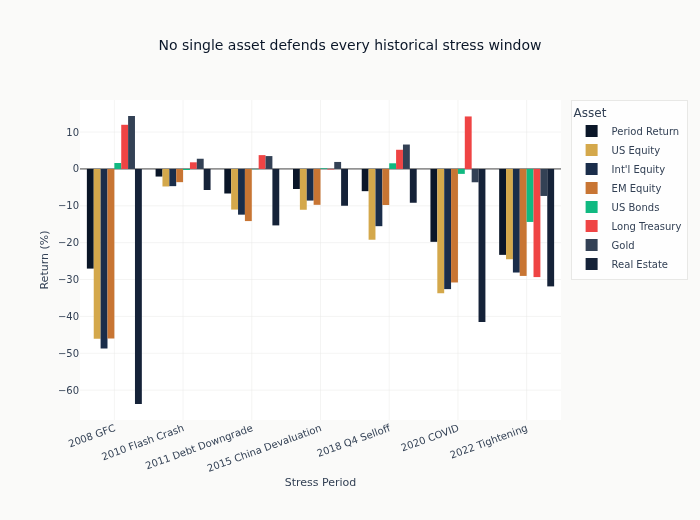

In [11]:
# Visualize stress period returns
stress_df = pl.DataFrame(
    [
        {
            "Period": name,
            "Period Return": result["cum_return"] * 100,
            **{SYMBOLS[symbol]: value * 100 for symbol, value in result["asset_returns"].items()},
        }
        for name, result in stress_results.items()
    ]
)
stress_long = stress_df.unpivot(
    index="Period", variable_name="Asset", value_name="Return"
).to_pandas()

fig = px.bar(
    stress_long,
    x="Period",
    y="Return",
    color="Asset",
    barmode="group",
    title="No single asset defends every historical stress window",
    color_discrete_sequence=[
        COLORS["blue"],
        COLORS["amber"],
        COLORS["slate"],
        COLORS["copper"],
        COLORS["positive"],
        COLORS["negative"],
        COLORS["neutral"],
        COLORS["blue_light"],
    ],
)
fig.update_layout(
    xaxis_title="Stress Period",
    yaxis_title="Return (%)",
    height=520,
    margin={"b": 100},
)
fig.update_xaxes(
    tickmode="array",
    tickvals=list(STRESS_PLOT_LABELS),
    ticktext=list(STRESS_PLOT_LABELS.values()),
    tickangle=-20,
    automargin=True,
)
show_plotly_with_alt(
    fig,
    "Grouped bars of return by allocation for each historical crisis window. The ordering of the allocations differs between the equity-led selloffs and the 2022 rate-led one.",
)

The grouped bars make an important point for governance: which allocations hold up and which
give way changes materially by crisis type, so one historical event is not enough to size a
risk limit on.

## 3. Portfolio Comparison Under Stress

Compare different portfolio allocations during stress periods.

In [12]:
# Define portfolio allocations
PORTFOLIOS = {
    "60/40 Stocks/Bonds": {"SPY": 0.60, "AGG": 0.40},
    "All Weather": {"SPY": 0.30, "TLT": 0.40, "GLD": 0.15, "VNQ": 0.15},
    "Aggressive Equity": {"SPY": 0.60, "EFA": 0.20, "EEM": 0.20},
    "Defensive": {"AGG": 0.40, "TLT": 0.30, "GLD": 0.20, "SPY": 0.10},
}

The comparison helper applies the same explicit close endpoints and constant-weight aggregation
to every allocation, producing one tidy row per portfolio-window pair.

In [13]:
def compare_portfolios_stress(
    returns: pl.DataFrame,
    portfolios: dict[str, dict[str, float]],
    stress_periods: dict[str, tuple],
) -> pl.DataFrame:
    """Compare portfolio performance across stress periods."""
    results = []

    for period_name, (start, end) in stress_periods.items():
        for port_name, weights in portfolios.items():
            result = analyze_stress_period(returns, start, end, weights)
            results.append(
                {
                    "Period": period_name,
                    "Portfolio": port_name,
                    "Return": result["cum_return"] * 100,
                    "Max DD": result["max_drawdown"] * 100,
                    "Worst Day": result["worst_day"] * 100,
                }
            )

    return pl.DataFrame(results)

In [14]:
comparison_df = compare_portfolios_stress(returns, PORTFOLIOS, STRESS_PERIODS)

pivot_return = comparison_df.pivot(on="Portfolio", index="Period", values="Return")
portfolio_order = list(PORTFOLIOS)
pivot_return_pd = pivot_return.to_pandas().set_index("Period")

Comparing allocations across the same crisis windows highlights the tradeoff between protection
and participation. Defensive mixes lose less in equity crashes, but they are not uniformly best
once the stress comes from rates instead of growth.

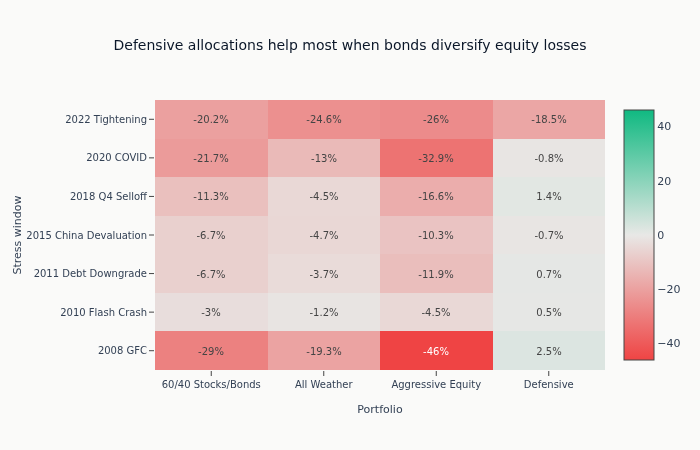

In [15]:
# Heatmap of stress performance
fig = go.Figure(
    data=go.Heatmap(
        z=pivot_return.select(portfolio_order).to_numpy(),
        x=portfolio_order,
        y=pivot_return["Period"].to_list(),
        colorscale=ml4t_diverging(),
        zmid=0,
        text=np.round(pivot_return.select(portfolio_order).to_numpy(), 1),
        texttemplate="%{text}%",
        textfont={"size": 10},
    )
)

fig.update_layout(
    title="Defensive allocations help most when bonds diversify equity losses",
    height=450,
    xaxis_title="Portfolio",
    yaxis_title="Stress window",
    margin={"l": 155},
)
fig.update_yaxes(
    tickmode="array",
    tickvals=list(STRESS_PLOT_LABELS),
    ticktext=list(STRESS_PLOT_LABELS.values()),
    automargin=True,
)
show_plotly_with_alt(
    fig,
    "A heatmap of allocation against crisis window, coloured by return, with the deepest losses concentrated in the equity-heavy allocations during the equity-led crises.",
)

The heatmap is the compact committee view: it shows immediately which portfolios are robust
across several historical episodes and which ones rely on one specific crisis pattern.

## 4. Hypothetical Scenario Analysis

Create user-defined stress scenarios to test portfolio resilience. These shock vectors are
hand-authored simultaneous moves. They are not estimated from a covariance matrix and should not
be interpreted as statistically calibrated correlated shocks.

Hypothetical scenarios let us test exposures that are plausible but not identical to any one
historical window. We start by defining a simple scenario object.

In [16]:
@dataclass
class StressScenario:
    """User-defined stress scenario."""

    name: str
    shocks: dict[str, float]  # Asset -> shock magnitude
    description: str = ""

In [17]:
# Define hypothetical scenarios
SCENARIOS = [
    StressScenario(
        name="Equity Crash (-30%)",
        shocks={
            "SPY": -0.30,
            "EFA": -0.35,
            "EEM": -0.40,
            "VNQ": -0.25,
            "AGG": 0.02,
            "TLT": 0.10,
            "GLD": 0.05,
        },
        description="Major equity selloff, flight to quality",
    ),
    StressScenario(
        name="Rising Rates (+200bps)",
        shocks={
            "SPY": -0.10,
            "EFA": -0.08,
            "EEM": -0.15,
            "VNQ": -0.20,
            "AGG": -0.10,
            "TLT": -0.25,
            "GLD": -0.05,
        },
        description="Fed tightening, bond selloff",
    ),
]

In [18]:
SCENARIOS.append(
    StressScenario(
        name="Stagflation",
        shocks={
            "SPY": -0.20,
            "EFA": -0.25,
            "EEM": -0.30,
            "VNQ": -0.15,
            "AGG": -0.05,
            "TLT": -0.10,
            "GLD": 0.20,
        },
        description="High inflation + recession",
    ),
)

In [19]:
SCENARIOS.extend(
    [
        StressScenario(
            name="Deflation Crisis",
            shocks={
                "SPY": -0.25,
                "EFA": -0.30,
                "EEM": -0.35,
                "VNQ": -0.30,
                "AGG": 0.05,
                "TLT": 0.20,
                "GLD": -0.10,
            },
            description="Severe deflation, long bonds rally",
        ),
        StressScenario(
            name="EM Crisis",
            shocks={
                "SPY": -0.10,
                "EFA": -0.15,
                "EEM": -0.40,
                "VNQ": -0.05,
                "AGG": 0.02,
                "TLT": 0.05,
                "GLD": 0.10,
            },
            description="Emerging market contagion",
        ),
    ]
)

Applying a scenario is just a weighted sum of the asset shocks. Keeping that logic separate
makes the scenario table easier to audit and reuse.

In [20]:
def apply_scenario(
    portfolio_weights: dict[str, float],
    scenario: StressScenario,
) -> dict:
    """Calculate portfolio impact from a stress scenario."""
    if not np.isclose(sum(portfolio_weights.values()), 1.0, rtol=0, atol=1e-12):
        raise ValueError("portfolio weights must sum to one")
    missing_shocks = sorted(set(portfolio_weights) - set(scenario.shocks))
    if missing_shocks:
        raise KeyError(f"scenario is missing shocks for: {missing_shocks}")
    portfolio_shock = sum(
        weight * scenario.shocks[asset] for asset, weight in portfolio_weights.items()
    )

    return {
        "scenario": scenario.name,
        "portfolio_shock": portfolio_shock,
        "description": scenario.description,
    }

In [21]:
# Apply scenarios to all portfolios
print("Hypothetical Scenario Analysis")
print("=" * 70)

scenario_results = []
for scenario in SCENARIOS:
    print(f"\n{scenario.name}: {scenario.description}")
    for port_name, weights in PORTFOLIOS.items():
        result = apply_scenario(weights, scenario)
        scenario_results.append(
            {
                "Scenario": scenario.name,
                "Portfolio": port_name,
                "Impact": result["portfolio_shock"] * 100,
            }
        )
        print(f"  {port_name}: {result['portfolio_shock'] * 100:+.1f}%")

scenario_df = pl.DataFrame(scenario_results)

Hypothetical Scenario Analysis

Equity Crash (-30%): Major equity selloff, flight to quality
  60/40 Stocks/Bonds: -17.2%
  All Weather: -8.0%
  Aggressive Equity: -33.0%
  Defensive: +1.8%

Rising Rates (+200bps): Fed tightening, bond selloff
  60/40 Stocks/Bonds: -10.0%
  All Weather: -16.8%
  Aggressive Equity: -10.6%
  Defensive: -13.5%

Stagflation: High inflation + recession
  60/40 Stocks/Bonds: -14.0%
  All Weather: -9.2%
  Aggressive Equity: -23.0%
  Defensive: -3.0%

Deflation Crisis: Severe deflation, long bonds rally
  60/40 Stocks/Bonds: -13.0%
  All Weather: -5.5%
  Aggressive Equity: -28.0%
  Defensive: +3.5%

EM Crisis: Emerging market contagion
  60/40 Stocks/Bonds: -5.2%
  All Weather: -0.2%
  Aggressive Equity: -17.0%
  Defensive: +3.3%


The scenario table is the fastest way to test whether a portfolio is accidentally concentrated
in one macro view, such as falling rates or benign inflation.

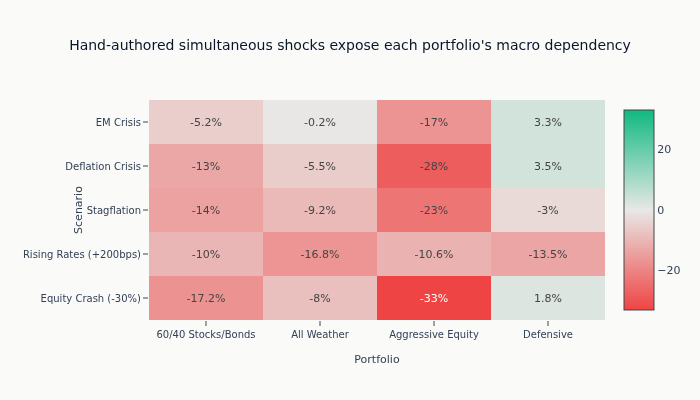

In [22]:
# Visualize scenario impacts
pivot_scenario = scenario_df.pivot(on="Portfolio", index="Scenario", values="Impact")

fig = go.Figure(
    data=go.Heatmap(
        z=pivot_scenario.select(portfolio_order).to_numpy(),
        x=portfolio_order,
        y=pivot_scenario["Scenario"].to_list(),
        colorscale=ml4t_diverging(),
        zmid=0,
        text=np.round(pivot_scenario.select(portfolio_order).to_numpy(), 1),
        texttemplate="%{text}%",
    )
)

fig.update_layout(
    title="Hand-authored simultaneous shocks expose each portfolio's macro dependency",
    height=400,
    xaxis_title="Portfolio",
    yaxis_title="Scenario",
    margin={"l": 135},
)
fig.update_yaxes(automargin=True)
show_plotly_with_alt(
    fig,
    "A heatmap of allocation against hand-authored scenario, coloured by modelled impact. The rate-shock row separates the allocations differently from the equity-shock rows.",
)

The hypothetical heatmap complements the historical one: it shows the same diversification
question under shocks we choose deliberately rather than inherit from history.

## 5. Univariate Portfolio-Return Student-t Monte Carlo

Simulate the *portfolio-return series*, not the underlying asset returns, under a symmetric
Student-t distribution fitted to full-sample mean, variance, and excess kurtosis. Daily draws are
iid: the model omits serial dependence, volatility clustering, regime transitions, and changing
cross-asset dependence. Constant weights imply daily rebalancing before costs. Student-t support
is unbounded below, while a simple return cannot fall below losing everything; the
implementation raises if a seeded sample crosses that boundary rather than compounding an
impossible path.

In [23]:
def student_t_parameters(excess_kurtosis: float, target_std: float) -> tuple[float, float]:
    """Return Student-t degrees of freedom and variance-matched scale."""

    if excess_kurtosis <= 0:
        raise ValueError("a Student-t distribution cannot match non-positive excess kurtosis")
    if target_std <= 0:
        raise ValueError("target standard deviation must be positive")
    df_t = 6 / excess_kurtosis + 4
    scale_t = target_std * np.sqrt((df_t - 2) / df_t)
    implied_variance = scale_t**2 * df_t / (df_t - 2)
    np.testing.assert_allclose(implied_variance, target_std**2, rtol=1e-12, atol=0)
    return df_t, scale_t

A local generator makes the iid and support assumptions executable. It returns the sampled daily
paths with the fitted parameters and refuses to compound any invalid simple return.

In [24]:
def simulate_student_t_paths(
    mu: float,
    sigma: float,
    excess_kurtosis: float,
    n_simulations: int,
    horizon_days: int,
    seed: int,
) -> tuple[np.ndarray, float, float]:
    """Draw iid symmetric Student-t paths with variance-matched scale."""

    df_t, scale_t = student_t_parameters(excess_kurtosis, sigma)
    rng = np.random.default_rng(seed)
    simulated_daily = stats.t.rvs(
        df_t,
        loc=mu,
        scale=scale_t,
        size=(n_simulations, horizon_days),
        random_state=rng,
    )
    support_violations = int((simulated_daily <= -1).sum())
    if support_violations:
        raise ValueError(f"Student-t sampled {support_violations} simple returns at or below -100%")
    return simulated_daily, df_t, scale_t

Tail summarization is separate from sampling so the conventions stay visible. VaR is the lower
quantile of the simulated cumulative returns; CVaR is the mean of every path at or below the
first of the configured confidence levels.

In [25]:
def summarize_simulated_returns(
    simulated_cum: np.ndarray,
    confidence_levels: tuple[float, ...],
) -> dict[str, float]:
    """Summarize simulated cumulative-return tails."""

    var_results = {
        f"VaR_{level:.1%}": np.percentile(simulated_cum, (1 - level) * 100)
        for level in confidence_levels
    }
    cvar_95 = simulated_cum[simulated_cum <= var_results["VaR_95.0%"]].mean()
    return {
        "mean": simulated_cum.mean(),
        "min": simulated_cum.min(),
        **var_results,
        "CVaR_95": cvar_95,
    }

The portfolio-level wrapper compounds the daily paths, attaches their fitted diagnostics, and
retains the raw distribution for visual comparison.

In [26]:
def monte_carlo_stress_test(
    returns: pl.DataFrame,
    portfolio_weights: dict[str, float],
    n_simulations: int = N_SIMULATIONS,
    horizon_days: int = HORIZON_DAYS,
    confidence_levels: tuple[float, ...] = CONFIDENCE_LEVELS,
    seed: int = SEED,
) -> dict:
    """
    Univariate portfolio-return Student-t Monte Carlo for tail VaR/CVaR.

    Simulate independent symmetric Student-t portfolio returns with degrees
    of freedom matched to empirical excess kurtosis and scale adjusted to
    reproduce the target daily variance.
    """
    portfolio_returns = aggregate_portfolio_returns(returns, portfolio_weights)[
        "portfolio_return"
    ].to_numpy()

    mu = portfolio_returns.mean()
    sigma = portfolio_returns.std(ddof=1)
    empirical_skew = stats.skew(portfolio_returns, bias=False)
    excess_kurtosis = stats.kurtosis(portfolio_returns, fisher=True, bias=False)
    simulated_daily, df_t, scale_t = simulate_student_t_paths(
        mu, sigma, excess_kurtosis, n_simulations, horizon_days, seed
    )
    simulated_cum = (1 + simulated_daily).prod(axis=1) - 1

    return {
        **summarize_simulated_returns(simulated_cum, confidence_levels),
        "df_t": df_t,
        "scale_t": scale_t,
        "empirical_excess_kurtosis": excess_kurtosis,
        "empirical_skew_diagnostic_only": empirical_skew,
        "support_violations": 0,
        "distribution": simulated_cum,
    }

In [27]:
# Run Monte Carlo for each portfolio
print(f"Monte Carlo stress test: {N_SIMULATIONS:,} paths over {HORIZON_DAYS} trading days")
print("=" * 70)

mc_results = {}
for port_name, weights in PORTFOLIOS.items():
    result = monte_carlo_stress_test(returns, weights)
    mc_results[port_name] = result

    print(f"\n{port_name}:")
    print(f"  Expected:    {result['mean'] * 100:+.2f}%")
    print(f"  95% VaR:     {result['VaR_95.0%'] * 100:.2f}%")
    print(f"  99% VaR:     {result['VaR_99.0%'] * 100:.2f}%")
    print(f"  99.9% VaR:   {result['VaR_99.9%'] * 100:.2f}%")
    print(f"  95% CVaR:    {result['CVaR_95'] * 100:.2f}%")
    print(f"  Worst Case:  {result['min'] * 100:.2f}%")
    print(f"  Student-t df: {result['df_t']:.2f} (symmetric; skew not fitted)")
    print(f"  Support violations: {result['support_violations']}")

Monte Carlo stress test: 10,000 paths over 20 trading days

60/40 Stocks/Bonds:
  Expected:    +0.60%
  95% VaR:     -4.94%
  99% VaR:     -7.54%
  99.9% VaR:   -10.42%
  95% CVaR:    -6.51%
  Worst Case:  -12.07%
  Student-t df: 4.33 (symmetric; skew not fitted)
  Support violations: 0

All Weather:
  Expected:    +0.59%
  95% VaR:     -4.38%
  99% VaR:     -6.68%
  99.9% VaR:   -9.35%
  95% CVaR:    -5.79%
  Worst Case:  -15.47%
  Student-t df: 4.71 (symmetric; skew not fitted)
  Support violations: 0

Aggressive Equity:
  Expected:    +0.68%
  95% VaR:     -8.95%
  99% VaR:     -13.03%
  99.9% VaR:   -18.04%
  95% CVaR:    -11.58%
  Worst Case:  -41.89%
  Student-t df: 4.38 (symmetric; skew not fitted)
  Support violations: 0

Defensive:
  Expected:    +0.41%
  95% VaR:     -3.14%
  99% VaR:     -4.56%
  99.9% VaR:   -6.62%
  95% CVaR:    -4.08%
  Worst Case:  -9.90%
  Student-t df: 4.98 (symmetric; skew not fitted)
  Support violations: 0


The Monte Carlo block is not a forecast of the next crisis. It maps full-sample portfolio moments
into one possible tail range under a symmetric iid law. Empirical skew is displayed only as a
diagnostic and is not fitted by the symmetric Student-t distribution.

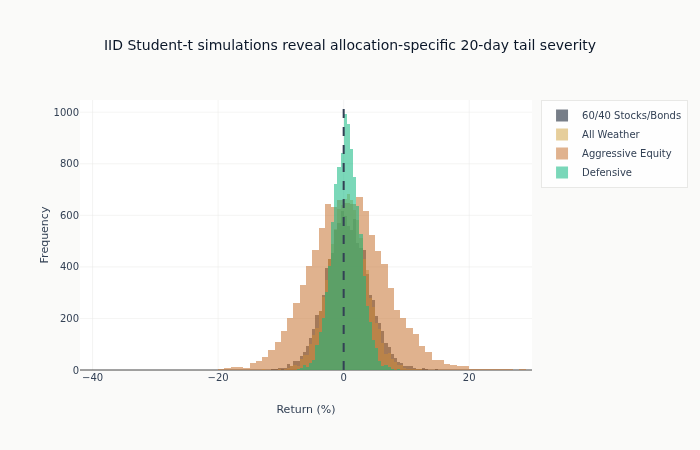

In [28]:
# Visualize return distributions
fig = go.Figure()

for port_name, result in mc_results.items():
    fig.add_trace(
        go.Histogram(x=result["distribution"] * 100, name=port_name, opacity=0.55, nbinsx=100)
    )

fig.add_vline(x=0, line_dash="dash", line_color=COLORS["neutral"])

fig.update_layout(
    title="IID Student-t simulations reveal allocation-specific 20-day tail severity",
    xaxis_title="Return (%)",
    yaxis_title="Frequency",
    barmode="overlay",
    height=450,
    colorway=ml4t_palette(4, categorical=True),
)
show_plotly_with_alt(
    fig,
    "Four overlapping histograms of simulated twenty-day cumulative return, one per allocation, with a dashed line at zero. The equity-heavy distributions are visibly wider on both sides.",
)

These simulated distributions are most useful for ranking tail severity across allocations.
The left tail is the key object because that is where capital and governance constraints bind.

**Distribution parameters by portfolio.** For empirical excess kurtosis
$\kappa > 0$, the Student-t degrees of freedom are $\nu = 6 / \kappa + 4$.
Its scale is $s = \sigma\sqrt{(\nu-2)/\nu}$, which preserves the target daily
variance because $\operatorname{Var}(T)=s^2\nu/(\nu-2)$. Lower $\nu$ means
heavier tails. Skew is diagnostic only because the fitted law is symmetric.

In [29]:
mc_df_table = pl.DataFrame(
    [
        {
            "portfolio": name,
            "df_t": result["df_t"],
            "excess_kurtosis": result["empirical_excess_kurtosis"],
            "empirical_skew_diagnostic_only": result["empirical_skew_diagnostic_only"],
            "support_violations": result["support_violations"],
        }
        for name, result in mc_results.items()
    ]
)
display(mc_df_table.to_pandas().round(3))

,portfolio,df_t,excess_kurtosis,empirical_skew_diagnostic_only,support_violations
0,60/40 Stocks/Bonds,4.331,18.140,0.126,0
1,All Weather,4.709,8.464,-0.037,0
2,Aggressive Equity,4.380,15.801,0.086,0
3,Defensive,4.983,6.103,-0.303,0


## 6. Sensitivity Analysis

Test how portfolio performance changes with parameter variations.

In [30]:
def sensitivity_analysis(
    returns: pl.DataFrame,
    base_weights: dict[str, float],
    asset_to_vary: str,
    weight_range: np.ndarray,
    adjust_asset: str,  # Asset to adjust when varying
) -> pl.DataFrame:
    """
    Analyze sensitivity of portfolio metrics to weight changes.

    When increasing one asset's weight, decrease another's proportionally.
    """
    results = []

    for new_weight in weight_range:
        # Adjust weights
        weights = base_weights.copy()
        weight_change = new_weight - base_weights[asset_to_vary]
        weights[asset_to_vary] = new_weight
        weights[adjust_asset] = base_weights[adjust_asset] - weight_change

        port_returns = aggregate_portfolio_returns(returns, weights)["portfolio_return"].to_numpy()
        annual_ret = port_returns.mean() * 252
        annual_vol = port_returns.std(ddof=1) * np.sqrt(252)
        sharpe = annual_ret / annual_vol
        max_dd = max_drawdown(port_returns)

        results.append(
            {
                "weight": new_weight,
                "annual_return": annual_ret,
                "volatility": annual_vol,
                "sharpe": sharpe,
                "max_drawdown": max_dd,
            }
        )

    return pl.DataFrame(results)

Sensitivity analysis isolates one design choice at a time. Here we vary equity weight inside a
simple 60/40 portfolio to see how return, volatility, and drawdown move together.

In [31]:
# Sensitivity: Vary equity allocation (SPY) in 60/40 portfolio
base_60_40 = {"SPY": 0.60, "AGG": 0.40}
weight_range = np.linspace(0.20, 0.80, 13)

sensitivity_df = sensitivity_analysis(returns, base_60_40, "SPY", weight_range, "AGG")
sensitivity_pd = sensitivity_df.to_pandas()

The four metrics are drawn as separate panels on a shared horizontal axis. They are measured in
different units and are not comparable to each other; putting them on one vertical scale would
suggest otherwise.

In [32]:
fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=[
        "Return vs Equity %",
        "Volatility vs Equity %",
        "Sharpe vs Equity %",
        "Max DD vs Equity %",
    ],
)

fig.add_trace(
    go.Scatter(
        x=sensitivity_pd["weight"] * 100,
        y=sensitivity_pd["annual_return"] * 100,
        mode="lines+markers",
        line_color=COLORS["blue"],
    ),
    row=1,
    col=1,
)

_ = fig.add_trace(
    go.Scatter(
        x=sensitivity_pd["weight"] * 100,
        y=sensitivity_pd["volatility"] * 100,
        mode="lines+markers",
        line_color=COLORS["amber"],
    ),
    row=1,
    col=2,
)

With the upper row held in memory, the lower row completes the figure before the notebook renders
it. This prevents an incomplete intermediate Plotly panel from appearing in the output.

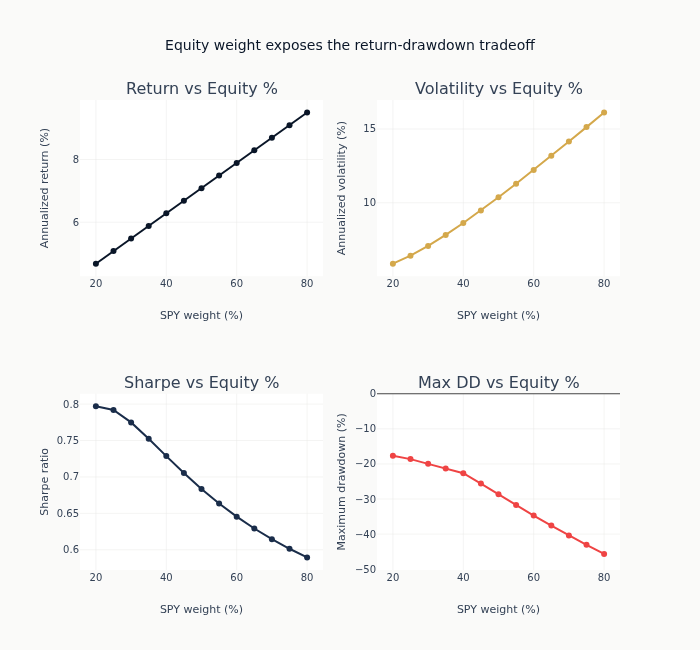

In [33]:
fig.add_trace(
    go.Scatter(
        x=sensitivity_pd["weight"] * 100,
        y=sensitivity_pd["sharpe"],
        mode="lines+markers",
        line_color=COLORS["slate"],
    ),
    row=2,
    col=1,
)

fig.add_trace(
    go.Scatter(
        x=sensitivity_pd["weight"] * 100,
        y=sensitivity_pd["max_drawdown"] * 100,
        mode="lines+markers",
        line_color=COLORS["negative"],
    ),
    row=2,
    col=2,
)

fig.update_xaxes(title_text="SPY weight (%)", row=1, col=1)
fig.update_xaxes(title_text="SPY weight (%)", row=1, col=2)
fig.update_xaxes(title_text="SPY weight (%)", row=2, col=1)
fig.update_xaxes(title_text="SPY weight (%)", row=2, col=2)
fig.update_yaxes(title_text="Annualized return (%)", row=1, col=1)
fig.update_yaxes(title_text="Annualized volatility (%)", row=1, col=2)
fig.update_yaxes(title_text="Sharpe ratio", row=2, col=1)
fig.update_yaxes(
    title_text="Maximum drawdown (%)",
    range=[sensitivity_df["max_drawdown"].min() * 110, 0],
    row=2,
    col=2,
)
fig.update_layout(
    title="Equity weight exposes the return-drawdown tradeoff", height=650, showlegend=False
)
show_plotly_with_alt(
    fig,
    "Four panels of sensitivity metrics against shock size on a shared horizontal axis, each with its own vertical units, showing how each allocation degrades as the shock deepens.",
)

This panel treats stress management as a frontier problem rather than a single optimum. It shows
how return, volatility, risk-adjusted performance, and drawdown change together as equity weight
rises; it does not assume that the in-sample Sharpe-maximizing mix will persist out of sample.

## 7. Regime-Based Stress Analysis with Lagged State

A label applied to return day $t$ must be known before that return is realized. Trend and
volatility therefore use the previous 60 completed SPY sessions. Their high-volatility reference
is an expanding median of trailing volatility, also lagged one session. This point-in-time state
avoids both full-sample median lookahead and same-day return endogeneity. The labels remain a
simple diagnostic rule, not an optimized or validated trading signal.

In [34]:
def classify_regime(returns: pl.DataFrame, lookback: int = REGIME_LOOKBACK) -> pl.DataFrame:
    """Classify day t from SPY state available through the close of t-1."""

    values = returns["SPY"].to_numpy()
    trailing_vol = np.full(values.size, np.nan)
    labels: list[str | None] = [None] * values.size
    for end in range(lookback - 1, values.size):
        trailing_vol[end] = values[end - lookback + 1 : end + 1].std(ddof=1) * np.sqrt(252)

    for t in range(lookback, values.size):
        historical_vol = trailing_vol[:t][np.isfinite(trailing_vol[:t])]
        if historical_vol.size < lookback:
            continue
        trend = values[t - lookback : t].mean() * 252
        volatility = trailing_vol[t - 1]
        vol_reference = np.median(historical_vol)
        if trend < BEAR_TREND_THRESHOLD:
            labels[t] = "Bear"
        elif trend > BULL_TREND_THRESHOLD and volatility < vol_reference:
            labels[t] = "Bull"
        elif volatility > vol_reference * HIGH_VOL_MULTIPLE:
            labels[t] = "High Vol"
        else:
            labels[t] = "Calm"

    return pl.DataFrame({"timestamp": returns["timestamp"], "regime": labels})

In [35]:
# Classify regimes using SPY
regimes = classify_regime(returns.select("timestamp", "SPY"))

print("Market Regime Distribution")
print("=" * 40)
display(regimes.group_by("regime", maintain_order=True).len().to_pandas())

Market Regime Distribution


,regime,len
0,None,119
1,Bull,1797
2,Calm,937
3,Bear,974
4,High Vol,450


Regime counts tell us whether the sample is dominated by calm markets or contains enough stressed
observations to make the regime comparison informative.

The next helper summarizes portfolio behavior conditional on the market regime labels above.

In [36]:
def analyze_by_regime(
    returns: pl.DataFrame,
    regimes: pl.DataFrame,
    portfolio_weights: dict[str, float],
) -> pl.DataFrame:
    """Calculate conditional one-day portfolio metrics by lagged regime."""

    aligned = aggregate_portfolio_returns(returns, portfolio_weights).join(regimes, on="timestamp")
    return (
        aligned.drop_nulls("regime")
        .group_by("regime", maintain_order=True)
        .agg(
            pl.len().alias("Days"),
            (pl.col("portfolio_return").mean() * 252 * 100).alias("Ann Return"),
            (pl.col("portfolio_return").std() * np.sqrt(252) * 100).alias("Ann Vol"),
            (
                pl.col("portfolio_return").mean() / pl.col("portfolio_return").std() * np.sqrt(252)
            ).alias("Sharpe"),
            (pl.col("portfolio_return").min() * 100).alias("Worst Day"),
        )
        .filter(pl.col("Days") > 20)
        .rename({"regime": "Regime"})
    )

In [37]:
# Analyze each portfolio by regime
print("\nPerformance by Market Regime")
print("=" * 70)

regime_results = {}
regime_tables = []
for port_name, weights in PORTFOLIOS.items():
    regime_df = analyze_by_regime(returns, regimes, weights)
    regime_results[port_name] = regime_df
    regime_tables.append(regime_df.with_columns(pl.lit(port_name).alias("Portfolio")))

regime_summary = pl.concat(regime_tables).select(
    "Portfolio", "Regime", "Days", "Ann Return", "Ann Vol", "Sharpe", "Worst Day"
)
display(regime_summary.to_pandas().round(2))


Performance by Market Regime


,Portfolio,Regime,Days,Ann Return,Ann Vol,Sharpe,Worst Day
0,60/40 Stocks/Bonds,Bull,1797,6.21,7.02,0.88,-2.35
1,60/40 Stocks/Bonds,Calm,937,9.90,8.58,1.15,-2.69
2,60/40 Stocks/Bonds,Bear,974,12.73,20.46,0.62,-7.34
3,60/40 Stocks/Bonds,High Vol,450,-0.36,12.31,-0.03,-3.53
4,All Weather,Bull,1797,6.53,7.65,0.85,-2.83
5,All Weather,Calm,937,8.11,8.21,0.99,-2.21
6,All Weather,Bear,974,13.87,16.51,0.84,-5.50
7,All Weather,High Vol,450,2.26,11.58,0.20,-2.41
8,Aggressive Equity,Bull,1797,3.08,12.99,0.24,-5.09
9,Aggressive Equity,Calm,937,12.85,14.97,0.86,-3.77


Conditional one-day metrics close the loop between static stress tests and time-varying risk. A
portfolio that looks acceptable in full-sample averages can still have poor returns in bear or
high-vol states. Maximum drawdown is intentionally absent: concatenating noncontiguous days from
one regime would invent a wealth path that no investor experienced.

## 8. Stress Test Summary Report

A compact decision table retains the worst historical window, worst hand-authored scenario, and
simulated tail metrics for each allocation without recomputing or repeating earlier sections.

In [38]:
summary_rows = []
for portfolio_name in PORTFOLIOS:
    historical = (
        comparison_df.filter(pl.col("Portfolio") == portfolio_name)
        .sort("Return")
        .row(0, named=True)
    )
    hypothetical = (
        scenario_df.filter(pl.col("Portfolio") == portfolio_name).sort("Impact").row(0, named=True)
    )
    mc = mc_results[portfolio_name]
    summary_rows.append(
        {
            "Portfolio": portfolio_name,
            "Worst Historical Window": historical["Period"],
            "Historical Return (%)": historical["Return"],
            "Worst Hand-Authored Scenario": hypothetical["Scenario"],
            "Scenario Impact (%)": hypothetical["Impact"],
            "Simulated 95% VaR (%)": mc["VaR_95.0%"] * 100,
            "Simulated 95% CVaR (%)": mc["CVaR_95"] * 100,
        }
    )

stress_report = pl.DataFrame(summary_rows)
display(stress_report.to_pandas().round(2))

,Portfolio,Worst Historical Window,Historical Return (%),Worst Hand-Authored Scenario,Scenario Impact (%),Simulated 95% VaR (%),Simulated 95% CVaR (%)
0,60/40 Stocks/Bonds,2008 GFC Selloff,-29.03,Equity Crash (-30%),-17.20,-4.94,-6.51
1,All Weather,2022 Tightening Jan-to-Oct Selloff,-24.64,Rising Rates (+200bps),-16.75,-4.38,-5.79
2,Aggressive Equity,2008 GFC Selloff,-46.03,Equity Crash (-30%),-33.00,-8.95,-11.58
3,Defensive,2022 Tightening Jan-to-Oct Selloff,-18.52,Rising Rates (+200bps),-13.50,-3.14,-4.08


## Key Takeaways

In [39]:
gfc = pivot_return_pd.loc["2008 GFC Selloff"]
tightening = pivot_return_pd.loc["2022 Tightening Jan-to-Oct Selloff"]
tail_cvar = {name: result["CVaR_95"] * 100 for name, result in mc_results.items()}
aggressive_bear = (
    regime_results["Aggressive Equity"].filter(pl.col("Regime") == "Bear").row(0, named=True)
)
gfc_best, gfc_worst = gfc.idxmax(), gfc.idxmin()
tightening_best, tightening_worst = tightening.idxmax(), tightening.idxmin()
tail_best = max(tail_cvar, key=tail_cvar.get)
tail_worst = min(tail_cvar, key=tail_cvar.get)
display(
    Markdown(
        f"In the 2008 selloff, {gfc_best} returned {gfc[gfc_best]:+.1f}% against "
        f"{gfc_worst}'s {gfc[gfc_worst]:+.1f}%. In the 2022 tightening the ordering changed: "
        f"{tightening_best} returned {tightening[tightening_best]:+.1f}% and "
        f"{tightening_worst} returned {tightening[tightening_worst]:+.1f}%. Simulated expected "
        f"shortfall runs from {tail_cvar[tail_best]:.1f}% for {tail_best} to "
        f"{tail_cvar[tail_worst]:.1f}% for {tail_worst}. Aggressive Equity's worst observed day "
        f"in a Bear state was {aggressive_bear['Worst Day']:.1f}%."
    )
)

In the 2008 selloff, Defensive returned +2.5% against Aggressive Equity's -46.0%. In the 2022 tightening the ordering changed: Defensive returned -18.5% and Aggressive Equity returned -26.0%. Simulated expected shortfall runs from -4.1% for Defensive to -11.6% for Aggressive Equity. Aggressive Equity's worst observed day in a Bear state was -11.3%.

1. **Replay more than one crisis, because they are not the same shock.** In 2008 the assets that
   protected a portfolio were the ones with no equity exposure; in 2022 those same assets were
   the source of the loss, because the shock was to rates rather than to growth. An allocation
   tested against a single historical window is tested against a single mechanism.

2. **Write scenarios down as simultaneous shocks to every asset, not to one.** A crisis moves
   everything at once and moves correlations with it. Shocking one holding and leaving the rest
   at their historical relationships understates the loss precisely because it preserves the
   diversification that a crisis removes.

3. **Match the simulation's tails to the data before reading its quantiles.** A normal draw
   calibrated to the same mean and variance will understate every tail loss here, because daily
   returns have far more mass in the extremes than it allows. Matching the degrees of freedom to
   the observed excess kurtosis and rescaling to preserve the variance is the minimum.

4. **State what a simulation leaves out.** Independent daily draws contain no volatility
   clustering, no regime shifts and no change in cross-asset dependence, which is to say none of
   the mechanisms that make a real crisis a crisis. The result maps moments into a tail range; it
   is not a distribution of what happens next.

5. **Classify the market state from information that predates the day it labels.** Both the
   trend and the volatility here end at the previous close, and the reference level they are
   compared against expands through time. A state label that uses the day's own return will make
   any conditional risk number look far better than it is.

6. **Keep the deepest quantile in proportion to the number of paths behind it.** The most extreme
   confidence level reported here rests on a handful of the drawn paths, so it moves between
   seeds. Report it as an order of magnitude, or draw enough paths to pin it.

### Known limitations

- The historical windows are hand-dated. Moving a boundary by a few weeks moves every return in
  the replay, and nothing here tests how sensitive the comparison is to those dates.
- The hand-authored scenarios are judgements about what a shock would look like. They are
  internally consistent and are not calibrated to anything.
- The simulation fits one symmetric distribution to the whole sample. Real returns are skewed,
  the skew is reported as a diagnostic, and the symmetric fit does not use it.
- Constant weights imply the portfolio is rebalanced every day at no cost. Rebalancing daily
  through a crisis means trading the most in the least liquid conditions, which
  `18_transaction_costs` prices and this notebook does not.
- The regime thresholds are round numbers on this sample's own volatility distribution, so the
  states are relative to what this period contained.

**Next**: `07_drift_detection` moves from offline scenario tests to monitoring a live model for
the moment its inputs stop resembling what it was trained on.

**Book reference**: Chapter 19, Section 19.6.